In [96]:
import kaggle
import os
import random
import json
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as ipd
import datasets
import torch
import torchaudio
from pathlib import Path

In [97]:
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
set_seed()

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE = "cpu"
print('Device:', DEVICE)

Device: cpu


In [98]:
#!kaggle datasets download -d mfekadu/darpa-timit-acousticphonetic-continuous-speech -p timit --unzip

Now we need to explore the dataset

In [99]:
timit_path = "./timit/"
df_train = pd.read_csv(os.path.join(timit_path, 'train_data.csv'))
df_test = pd.read_csv(os.path.join(timit_path, 'test_data.csv'))
df = pd.concat([df_train, df_test])
df = df[df['is_converted_audio'] == False]
df_train = df[df['test_or_train'] == "TRAIN"]
df_test  = df[df['test_or_train'] == "TEST"]

In [100]:
df_train.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
5,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True


In [101]:
df_test.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TEST,DR4,MGMM0,SX139.WAV,TEST/DR4/MGMM0/SX139.WAV,TEST\\DR4\\MGMM0\\SX139.WAV,False,True,False,False,False
2,3.0,TEST,DR4,MGMM0,SX139.TXT,TEST/DR4/MGMM0/SX139.TXT,TEST\\DR4\\MGMM0\\SX139.TXT,False,False,False,False,True
3,4.0,TEST,DR4,MGMM0,SI499.WRD,TEST/DR4/MGMM0/SI499.WRD,TEST\\DR4\\MGMM0\\SI499.WRD,False,False,True,False,False
4,5.0,TEST,DR4,MGMM0,SX319.WRD,TEST/DR4/MGMM0/SX319.WRD,TEST\\DR4\\MGMM0\\SX319.WRD,False,False,True,False,False
5,6.0,TEST,DR4,MGMM0,SX319.PHN,TEST/DR4/MGMM0/SX319.PHN,TEST\\DR4\\MGMM0\\SX319.PHN,False,False,False,True,False


In [102]:
df.head()

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
5,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True


In [103]:
from typing import List, Dict, Iterable

# Канонічний mapping TIMIT 61 -> 39
PHONEME_61_TO_39: Dict[str, str] = {
    # vowels
    "iy": "iy",
    "ih": "ih",
    "eh": "eh",
    "ae": "ae",
    "ix": "ih",
    "ax": "ah",
    "ax-h": "ah",
    "ah": "ah",
    "uw": "uw",
    "ux": "uw",
    "uh": "uh",
    "ao": "aa",
    "aa": "aa",
    "ey": "ey",
    "ay": "ay",
    "oy": "oy",
    "aw": "aw",
    "ow": "ow",
    "er": "er",
    "axr": "er",

    # semivowels / liquids
    "l": "l",
    "el": "l",
    "r": "r",
    "y": "y",
    "w": "w",

    # nasals
    "m": "m",
    "em": "m",
    "n": "n",
    "en": "n",
    "nx": "n",
    "ng": "ng",
    "eng": "ng",

    # affricates / fricatives
    "ch": "ch",
    "jh": "jh",
    "dh": "dh",
    "z": "z",
    "zh": "sh",
    "v": "v",
    "f": "f",
    "th": "th",
    "s": "s",
    "sh": "sh",
    "hh": "hh",
    "hv": "hh",

    # stops
    "b": "b",
    "d": "d",
    "dx": "dx",
    "g": "g",
    "p": "p",
    "t": "t",
    "k": "k",

    # closures / silence / pauses
    "pcl": "h#",
    "tcl": "h#",
    "kcl": "h#",
    "bcl": "h#",
    "dcl": "h#",
    "gcl": "h#",
    "qcl": "h#",
    "h#": "h#",
    "#h": "h#",
    "pau": "h#",
    "epi": "h#",
    "q": "h#",
}

In [104]:
def map_phoneme_61_to_39(ph: str, mapping: Dict[str, str] = PHONEME_61_TO_39) -> str:
    ph = ph.strip()
    if ph not in mapping:
        raise ValueError(f"Unknown TIMIT phoneme: '{ph}'")
    return mapping[ph]

In [105]:
def map_phoneme_sequence_61_to_39(
    phonemes: Iterable[str],
    mapping: Dict[str, str] = PHONEME_61_TO_39
) -> List[str]:
    return [map_phoneme_61_to_39(ph, mapping) for ph in phonemes]

In [106]:
def map_phoneme_string_61_to_39(
    phoneme_text: str,
    mapping: Dict[str, str] = PHONEME_61_TO_39
) -> str:
    phonemes_61 = phoneme_text.strip().split()
    phonemes_39 = map_phoneme_sequence_61_to_39(phonemes_61, mapping)
    return " ".join(phonemes_39)

In [107]:
def read_timit_txt_file(txt_path: str | Path) -> str:
    txt_path = Path(txt_path)

    with txt_path.open("r", encoding="utf-8") as f:
        line = f.readline().strip()

    parts = line.split(maxsplit=2)
    if len(parts) < 3:
        raise ValueError(f"Invalid .TXT line in {txt_path}: {line!r}")

    return parts[2]

In [108]:
def read_timit_phn_file(phn_path: str | Path) -> List[str]:
    phonemes = []

    with open(phn_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            phonemes.append(parts[-1])

    return phonemes

In [109]:
def build_timit_utterance_record(
    wav_path: str | Path,
    drop_silence: bool = False,
) -> Dict:
    wav_path = Path(wav_path)

    if not wav_path.exists():
        raise FileNotFoundError(f"WAV file not found: {wav_path}")

    stem = wav_path.stem
    phn_path = wav_path.with_suffix(".PHN")
    txt_path = wav_path.with_suffix(".TXT")

    if not phn_path.exists():
        raise FileNotFoundError(f"PHN file not found for {wav_path}")
    if not txt_path.exists():
        raise FileNotFoundError(f"TXT file not found for {wav_path}")

    # .../TRAIN/DR1/FCJF0/SA1.WAV
    speaker_id = wav_path.parent.name
    dialect_region = wav_path.parent.parent.name
    split = wav_path.parent.parent.parent.name.upper()

    phonemes_61 = read_timit_phn_file(phn_path)

    phonemes_39 = map_phoneme_sequence_61_to_39(phonemes_61)

    phoneme_text_39 = " ".join(phonemes_39)

    text = read_timit_txt_file(txt_path)

    utt_id = f"{split}_{dialect_region}_{speaker_id}_{stem}"

    return {
        "utt_id": utt_id,
        "speaker_id": speaker_id,
        "dialect_region": dialect_region,
        "split": split,
        "wav_path": str(wav_path),
        "phonemes_39": phonemes_39,
        "phoneme_text_39": phoneme_text_39,
        "text": text,
    }

In [110]:
def build_timit_manifest(timit_root):

    wav_files = sorted(Path(timit_root).rglob("*.WAV"))

    records = []

    for wav_path in tqdm(wav_files):

        record = build_timit_utterance_record(wav_path)

        records.append(record)

    df = pd.DataFrame(records)

    return df

In [111]:
manifest_df = build_timit_manifest(timit_path)
manifest_df.head()

100%|██████████| 6300/6300 [00:01<00:00, 6030.26it/s]


,utt_id,speaker_id,dialect_region,split,wav_path,phonemes_39,phoneme_text_39,text
0,TEST_DR1_FAKS0_SA1,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SA1.WAV,"[h#, sh, iy, hh, ae, h#, d, y, er, h#, d, aa, ...",h# sh iy hh ae h# d y er h# d aa r h# k s uw d...,She had your dark suit in greasy wash water al...
1,TEST_DR1_FAKS0_SA2,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SA2.WAV,"[h#, d, ow, n, ae, s, h#, m, iy, h#, t, ih, h#...",h# d ow n ae s h# m iy h# t ih h# k eh r iy ih...,Don't ask me to carry an oily rag like that.
2,TEST_DR1_FAKS0_SI1573,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI1573.WAV,"[h#, hh, ih, z, h#, k, ae, h#, t, ih, n, w, ah...",h# hh ih z h# k ae h# t ih n w ah s th ih n ae...,His captain was thin and haggard and his beaut...
3,TEST_DR1_FAKS0_SI2203,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI2203.WAV,"[h#, dh, ih, r, iy, z, ah, n, z, f, er, dh, ih...",h# dh ih r iy z ah n z f er dh ih s h# d ay v ...,The reasons for this dive seemed foolish now.
4,TEST_DR1_FAKS0_SI943,FAKS0,DR1,TEST,timit/data/TEST/DR1/FAKS0/SI943.WAV,"[h#, p, er, h#, d, ah, h#, k, sh, ih, n, m, ey...",h# p er h# d ah h# k sh ih n m ey f aa l f aa ...,Production may fall far below expectations.


In [112]:
train_df = manifest_df[manifest_df["split"] == "TRAIN"]
test_df = manifest_df[manifest_df["split"] == "TEST"]

In [113]:
all_phonemes = set()

for seq in manifest_df["phonemes_39"]:
    all_phonemes.update(seq)

phoneme_list = sorted(list(all_phonemes))

In [114]:
phoneme2id = {p:i for i,p in enumerate(phoneme_list)}

id2phoneme = {i:p for p,i in phoneme2id.items()}


blank_id = len(phoneme2id)
num_classes = blank_id + 1

In [115]:
import torchaudio

def load_audio(path):

    waveform, sr = torchaudio.load(path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    return waveform.squeeze(0)

In [116]:
from transformers import Wav2Vec2Model
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

ssl_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

ssl_model.eval()

/Users/akravchuk/vscodeprojects/sound_processing/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [117]:
def split_dataframe(df, val_ratio=0.1, seed=SEED):
    n = len(df)

    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)

    val_size = int(n * val_ratio)

    val_idx = perm[:val_size]
    train_idx = perm[val_size:]

    train_df = df.iloc[train_idx.numpy()].reset_index(drop=True)
    val_df = df.iloc[val_idx.numpy()].reset_index(drop=True)

    return train_df, val_df

In [118]:
train_df, val_df = split_dataframe(train_df, val_ratio=0.1)

print(len(train_df))
print(len(val_df))
print(len(test_df))

4158
462
1680


In [119]:
def encode_phonemes(phonemes, phoneme2id):
    return [phoneme2id[p] for p in phonemes]

def decode_phonemes(ids, id2phoneme):
    return [id2phoneme[i] for i in ids]

In [120]:
sample_ids = encode_phonemes(train_df.iloc[0]["phonemes_39"], phoneme2id)
print(sample_ids)
print(decode_phonemes(sample_ids, id2phoneme))

[15, 8, 12, 0, 13, 15, 31, 23, 15, 14, 25, 3, 15, 23, 18, 18, 35, 23, 18, 23, 15]
['h#', 'dh', 'ey', 'aa', 'f', 'h#', 't', 'n', 'h#', 'g', 'ow', 'aw', 'h#', 'n', 'iy', 'iy', 'v', 'n', 'iy', 'n', 'h#']


In [121]:
ssl_model = ssl_model.to(DEVICE)
ssl_model.eval()

sample_row = train_df.iloc[0]
audio = load_audio(sample_row["wav_path"])

inputs = processor(
    audio,
    sampling_rate=16000,
    return_tensors="pt"
)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

with torch.no_grad():
    outputs = ssl_model(**inputs)

features = outputs.last_hidden_state.squeeze(0).cpu()
print(features.shape)
print(sample_row["phonemes_39"])

torch.Size([89, 768])
['h#', 'dh', 'ey', 'aa', 'f', 'h#', 't', 'n', 'h#', 'g', 'ow', 'aw', 'h#', 'n', 'iy', 'iy', 'v', 'n', 'iy', 'n', 'h#']


In [122]:
def extract_ssl_features(audio, processor, ssl_model, device, layer_index=-1):
    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ssl_model(**inputs, output_hidden_states=True)

    hidden_states = outputs.hidden_states
    features = hidden_states[layer_index].squeeze(0).cpu()   # [T, 768]
    return features

In [123]:
from tqdm.auto import tqdm
import torch

def build_cached_dataset(df, processor, ssl_model, device, phoneme2id, layer_index=-1):
    items = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        audio = load_audio(row["wav_path"])

        features = extract_ssl_features(
            audio=audio,
            processor=processor,
            ssl_model=ssl_model,
            device=device,
            layer_index=layer_index,
        )

        label_ids = encode_phonemes(row["phonemes_39"], phoneme2id)

        items.append({
            "utt_id": row["utt_id"],
            "features": features,  # [T, 768]
            "labels": torch.tensor(label_ids, dtype=torch.long),
            "phonemes_39": row["phonemes_39"],
            "text": row["text"],
        })

    return items

In [138]:
train_items = build_cached_dataset(
    train_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
)

val_items = build_cached_dataset(
    val_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
)

test_items = build_cached_dataset(
    test_df, processor, ssl_model, DEVICE, phoneme2id, layer_index=-1
)

#torch.save(train_items, "train_items_layer_last.pt")
#torch.save(val_items, "val_items_layer_last.pt")
torch.save(test_items, "test_items_layer_last.pt")

print(len(train_items), len(val_items), len(test_items))
print(train_items[0]["features"].shape)
print(train_items[0]["labels"])

100%|██████████| 1680/1680 [06:12<00:00,  4.51it/s]


4158 462 1680
torch.Size([89, 768])
tensor([15,  8, 12,  0, 13, 15, 31, 23, 15, 14, 25,  3, 15, 23, 18, 18, 35, 23,
        18, 23, 15])


In [125]:
from torch.utils.data import Dataset

class PhonemeDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

In [139]:
train_dataset = PhonemeDataset(train_items)
val_dataset = PhonemeDataset(val_items)
test_dataset = PhonemeDataset(test_items)

In [127]:
from torch.nn.utils.rnn import pad_sequence

def phoneme_collate_fn(batch):
    feature_list = [item["features"] for item in batch]
    label_list = [item["labels"] for item in batch]

    input_lengths = torch.tensor(
        [x.shape[0] for x in feature_list],
        dtype=torch.long
    )

    target_lengths = torch.tensor(
        [y.shape[0] for y in label_list],
        dtype=torch.long
    )

    padded_features = pad_sequence(feature_list, batch_first=True)
    flat_labels = torch.cat(label_list)

    return {
        "features": padded_features,
        "labels": flat_labels,
        "input_lengths": input_lengths,
        "target_lengths": target_lengths,
        "raw_labels": label_list,
        "utt_ids": [item["utt_id"] for item in batch],
        "phonemes_39": [item["phonemes_39"] for item in batch],
    }

In [140]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=phoneme_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=phoneme_collate_fn,
)

batch = next(iter(train_loader))

print(batch["features"].shape)      # [B, T_max, 768]
print(batch["labels"].shape)        # [sum(L_i)]
print(batch["input_lengths"])
print(batch["target_lengths"])

torch.Size([4, 148, 768])
torch.Size([156])
tensor([148, 119, 139, 129])
tensor([42, 35, 40, 39])


In [144]:
import torch.nn as nn

class LinearHead(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # x: [B, T, 768]
        return self.linear(x)  # [B, T, C]

class BiLSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        return self.classifier(out)


In [145]:
def build_head(head_name, input_dim, num_classes):
    if head_name == "linear":
        return LinearHead(input_dim=input_dim, num_classes=num_classes)
    elif head_name == "bilstm":
        return BiLSTMHead(
            input_dim=input_dim,
            hidden_dim=256,
            num_layers=2,
            num_classes=num_classes,
            dropout=0.1,
        )
    else:
        raise ValueError(f"Unknown head: {head_name}")

In [132]:
def greedy_ctc_decode(logits, blank_id):
    """
    logits: [B, T, C]
    return: List[List[int]]
    """
    pred_ids = logits.argmax(dim=-1)  # [B, T]
    results = []

    for seq in pred_ids:
        collapsed = []
        prev = None

        for idx in seq.tolist():
            if idx != prev and idx != blank_id:
                collapsed.append(idx)
            prev = idx

        results.append(collapsed)

    return results

In [133]:
def phoneme_distance(ref, hyp):
    n = len(ref)
    m = len(hyp)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]


def phoneme_error_rate(reference, hypothesis):
    if len(reference) == 0:
        return 0.0 if len(hypothesis) == 0 else 1.0
    return phoneme_distance(reference, hypothesis) / len(reference)

In [134]:
def train_one_epoch(model, loader, optimizer, ctc_loss, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        features = batch["features"].to(device)              # [B, T, 768]
        labels = batch["labels"].to(device)                  # [sum(L_i)]
        input_lengths = batch["input_lengths"].to(device)    # [B]
        target_lengths = batch["target_lengths"].to(device)  # [B]

        optimizer.zero_grad()

        logits = model(features)                             # [B, T, C]
        log_probs = logits.log_softmax(dim=-1).transpose(0, 1)  # [T, B, C]

        loss = ctc_loss(
            log_probs,
            labels,
            input_lengths,
            target_lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [135]:
def evaluate(model, loader, ctc_loss, device, blank_id, id2phoneme):
    model.eval()
    total_loss = 0.0
    total_per = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch in loader:
            features = batch["features"].to(device)
            labels = batch["labels"].to(device)
            input_lengths = batch["input_lengths"].to(device)
            target_lengths = batch["target_lengths"].to(device)

            logits = model(features)  # [B, T, C]
            log_probs = logits.log_softmax(dim=-1).transpose(0, 1)

            loss = ctc_loss(
                log_probs,
                labels,
                input_lengths,
                target_lengths
            )
            total_loss += loss.item()

            pred_id_seqs = greedy_ctc_decode(logits.cpu(), blank_id)

            ref_label_list = batch["raw_labels"] if "raw_labels" in batch else None
            if ref_label_list is None:
                raise ValueError("collate_fn must return raw_labels for evaluation")

            for pred_ids, ref_ids in zip(pred_id_seqs, ref_label_list):
                pred_ph = decode_phonemes(pred_ids, id2phoneme)
                ref_ph = decode_phonemes(ref_ids.tolist(), id2phoneme)

                per = phoneme_error_rate(ref_ph, pred_ph)
                total_per += per
                total_samples += 1

    avg_loss = total_loss / len(loader)
    avg_per = total_per / total_samples
    return avg_loss, avg_per

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=phoneme_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=phoneme_collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=phoneme_collate_fn,
)

In [ ]:
# num_epochs = 3
# best_val_per = float("inf")
# best_state = None

# for epoch in range(num_epochs):
#     train_loss = train_one_epoch(model, train_loader, optimizer, ctc_loss, DEVICE)
#     val_loss, val_per = evaluate(model, val_loader, ctc_loss, DEVICE, blank_id, id2phoneme)

#     print(f"Epoch {epoch+1}/{num_epochs}")
#     print(f"  train_loss: {train_loss:.4f}")
#     print(f"  val_loss:   {val_loss:.4f}")
#     print(f"  val_PER:    {val_per:.4f}")

#     if val_per < best_val_per:
#         best_val_per = val_per
#         best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

Epoch 1/5
  train_loss: 1.8538
  val_loss:   1.1533
  val_PER:    0.4123
Epoch 2/5
  train_loss: 1.0552
  val_loss:   0.9843
  val_PER:    0.3576
Epoch 3/5
  train_loss: 0.9410
  val_loss:   0.9045
  val_PER:    0.3370
Epoch 4/5
  train_loss: 0.8768
  val_loss:   0.8523
  val_PER:    0.3161
Epoch 5/5
  train_loss: 0.8326
  val_loss:   0.8134
  val_PER:    0.3043


In [ ]:
# test_loss, test_per = evaluate(
#     model,
#     test_loader,
#     ctc_loss,
#     "cpu",
#     blank_id,
#     id2phoneme
# )

# print(f"Test loss: {test_loss:.4f}")
# print(f"Test PER:  {test_per:.4f}")

Test loss: 0.8083
Test PER:  0.3000


In [142]:
def inspect_predictions(model, loader, device, blank_id, id2phoneme, max_examples=10):
    model.eval()
    shown = 0

    with torch.no_grad():
        for batch in loader:
            features = batch["features"].to(device)
            logits = model(features)

            pred_id_seqs = greedy_ctc_decode(logits.cpu(), blank_id)

            for utt_id, pred_ids, ref_ids in zip(
                batch["utt_ids"],
                pred_id_seqs,
                batch["raw_labels"]
            ):
                pred_ph = decode_phonemes(pred_ids, id2phoneme)
                ref_ph = decode_phonemes(ref_ids.tolist(), id2phoneme)
                per = phoneme_error_rate(ref_ph, pred_ph)

                print("=" * 80)
                print("utt_id:", utt_id)
                print("REF :", " ".join(ref_ph))
                print("PRED:", " ".join(pred_ph))
                print(f"PER : {per:.4f}")

                shown += 1
                if shown >= max_examples:
                    return

In [ ]:
# inspect_predictions(
#     model,
#     test_loader,
#     device="cpu",
#     blank_id=blank_id,
#     id2phoneme=id2phoneme,
#     max_examples=5
# )

utt_id: TEST_DR1_FAKS0_SA1
REF : h# sh iy hh ae h# d y er h# d aa r h# k s uw dx ih ng h# g r iy s iy w aa sh h# w aa dx er h# aa l y iy er h#
PRED: sh iy hh ae y er h# d aa r h# k s uw dx ih n g r iy s iy w aa sh w aa dx er aa l y ih er
PER : 0.2195
utt_id: TEST_DR1_FAKS0_SA2
REF : h# d ow n ae s h# m iy h# t ih h# k eh r iy ih n oy l iy r ae h# g l ay h# k dh ae h# h#
PRED: h# d ow n ae s h# k m iy dx ih h# k aa r iy ih n oy l iy r ae h# g l ay h# k dh ae h#
PER : 0.1471
utt_id: TEST_DR1_FAKS0_SI1573
REF : h# hh ih z h# k ae h# t ih n w ah s th ih n ae n hh ae h# g er h# d ih n ih z h# b y uw dx uw f l h# b uw h# t s h# w er w aa r n ih n h# sh ae h# b iy h#
PRED: hh ih z h# k ae h# p t eh n w ah s th ih n ah n hh ae sh g eh er h# d ih n hh ih z h# b dx ih f ah l b uw h# s z w er w aa r n ih n sh ae h# h# b iy
PER : 0.2833
utt_id: TEST_DR1_FAKS0_SI2203
REF : h# dh ih r iy z ah n z f er dh ih s h# d ay v s iy m h# d f uw l ih sh h# n aw h#
PRED: dh ih r iy z ah n s f aa dh ih h# dx ay

In [146]:
def get_cache_paths(layer_index, cache_dir="cache"):
    os.makedirs(cache_dir, exist_ok=True)
    suffix = f"layer_{layer_index}"
    return {
        "train": os.path.join(cache_dir, f"train_{suffix}.pt"),
        "val": os.path.join(cache_dir, f"val_{suffix}.pt"),
        "test": os.path.join(cache_dir, f"test_{suffix}.pt"),
    }

In [147]:
def prepare_cached_items_for_layer(
    layer_index,
    train_df,
    val_df,
    test_df,
    processor,
    ssl_model,
    ssl_device,
    phoneme2id,
    cache_dir="cache",
):
    paths = get_cache_paths(layer_index, cache_dir)

    if os.path.exists(paths["train"]):
        train_items = torch.load(paths["train"])
    else:
        train_items = build_cached_dataset(
            train_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(train_items, paths["train"])

    if os.path.exists(paths["val"]):
        val_items = torch.load(paths["val"])
    else:
        val_items = build_cached_dataset(
            val_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(val_items, paths["val"])

    if os.path.exists(paths["test"]):
        test_items = torch.load(paths["test"])
    else:
        test_items = build_cached_dataset(
            test_df, processor, ssl_model, ssl_device, phoneme2id, layer_index=layer_index
        )
        torch.save(test_items, paths["test"])

    return train_items, val_items, test_items

In [148]:
def run_experiment(
    layer_index,
    head_name,
    train_items,
    val_items,
    test_items,
    num_classes,
    blank_id,
    id2phoneme,
    train_device="cpu",
    batch_size=8,
    lr=1e-3,
    num_epochs=5,
):
    train_dataset = PhonemeDataset(train_items)
    val_dataset = PhonemeDataset(val_items)
    test_dataset = PhonemeDataset(test_items)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=phoneme_collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=phoneme_collate_fn,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=phoneme_collate_fn,
    )

    model = build_head(head_name, input_dim=768, num_classes=num_classes).to(train_device)
    ctc_loss = nn.CTCLoss(blank=blank_id, zero_infinity=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_per = float("inf")
    best_state = None
    history = []

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, ctc_loss, train_device)
        val_loss, val_per = evaluate(model, val_loader, ctc_loss, train_device, blank_id, id2phoneme)

        history.append({
            "epoch": epoch + 1,
            "layer_index": layer_index,
            "head": head_name,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_per": val_per,
        })

        if val_per < best_val_per:
            best_val_per = val_per
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    test_loss, test_per = evaluate(model, test_loader, ctc_loss, train_device, blank_id, id2phoneme)

    result = {
        "layer_index": layer_index,
        "head": head_name,
        "best_val_per": best_val_per,
        "test_loss": test_loss,
        "test_per": test_per,
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "lr": lr,
    }

    history_df = pd.DataFrame(history)
    return result, history_df, model

In [149]:
layers_to_try = [-1, -2, -3, 8, 6]
heads_to_try = ["linear", "bilstm"]

all_results = []
all_histories = []

SSL_DEVICE = DEVICE      # mps або cpu для feature extraction
TRAIN_DEVICE = "cpu"     # через CTCLoss

for layer_index in layers_to_try:
    train_items, val_items, test_items = prepare_cached_items_for_layer(
        layer_index=layer_index,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        processor=processor,
        ssl_model=ssl_model,
        ssl_device=SSL_DEVICE,
        phoneme2id=phoneme2id,
        cache_dir="cache",
    )

    for head_name in heads_to_try:
        print(f"\nRunning experiment: layer={layer_index}, head={head_name}")

        result, history_df, model = run_experiment(
            layer_index=layer_index,
            head_name=head_name,
            train_items=train_items,
            val_items=val_items,
            test_items=test_items,
            num_classes=num_classes,
            blank_id=blank_id,
            id2phoneme=id2phoneme,
            train_device=TRAIN_DEVICE,
            batch_size=8,
            lr=1e-3 if head_name == "linear" else 1e-4,
            num_epochs=5,
        )

        all_results.append(result)
        all_histories.append(history_df)

100%|██████████| 1680/1680 [04:44<00:00,  5.91it/s]



Running experiment: layer=-1, head=linear

Running experiment: layer=-1, head=bilstm


100%|██████████| 1680/1680 [05:19<00:00,  5.26it/s]



Running experiment: layer=-2, head=linear

Running experiment: layer=-2, head=bilstm


100%|██████████| 1680/1680 [04:47<00:00,  5.85it/s]



Running experiment: layer=-3, head=linear

Running experiment: layer=-3, head=bilstm


100%|██████████| 1680/1680 [04:41<00:00,  5.96it/s]



Running experiment: layer=8, head=linear

Running experiment: layer=8, head=bilstm


100%|██████████| 1680/1680 [04:55<00:00,  5.68it/s]



Running experiment: layer=6, head=linear

Running experiment: layer=6, head=bilstm


In [150]:
results_df = pd.DataFrame(all_results).sort_values("test_per")
results_df

,layer_index,head,best_val_per,test_loss,test_per,num_epochs,batch_size,lr
7,8,bilstm,0.102338,0.364111,0.103971,5,8,0.0001
9,6,bilstm,0.108487,0.409986,0.108484,5,8,0.0001
4,-3,linear,0.123618,0.404856,0.123387,5,8,0.0010
5,-3,bilstm,0.124739,0.344743,0.126230,5,8,0.0001
6,8,linear,0.127487,0.464269,0.127348,5,8,0.0010
8,6,linear,0.132619,0.467025,0.127935,5,8,0.0010
3,-2,bilstm,0.130638,0.417041,0.130707,5,8,0.0001
1,-1,bilstm,0.136838,0.447115,0.138230,5,8,0.0001
2,-2,linear,0.197653,0.548195,0.195978,5,8,0.0010
0,-1,linear,0.306718,0.809632,0.303001,5,8,0.0010


In [151]:
results_df = pd.DataFrame(all_results).sort_values("test_per")
results_df

,layer_index,head,best_val_per,test_loss,test_per,num_epochs,batch_size,lr
7,8,bilstm,0.102338,0.364111,0.103971,5,8,0.0001
9,6,bilstm,0.108487,0.409986,0.108484,5,8,0.0001
4,-3,linear,0.123618,0.404856,0.123387,5,8,0.0010
5,-3,bilstm,0.124739,0.344743,0.126230,5,8,0.0001
6,8,linear,0.127487,0.464269,0.127348,5,8,0.0010
8,6,linear,0.132619,0.467025,0.127935,5,8,0.0010
3,-2,bilstm,0.130638,0.417041,0.130707,5,8,0.0001
1,-1,bilstm,0.136838,0.447115,0.138230,5,8,0.0001
2,-2,linear,0.197653,0.548195,0.195978,5,8,0.0010
0,-1,linear,0.306718,0.809632,0.303001,5,8,0.0010


In [152]:
history_df = pd.concat(all_histories, ignore_index=True)
history_df.head()

,epoch,layer_index,head,train_loss,val_loss,val_per
0,1,-1,linear,1.870325,1.156659,0.418357
1,2,-1,linear,1.057030,0.985890,0.357163
2,3,-1,linear,0.942262,0.906467,0.331898
3,4,-1,linear,0.877899,0.855744,0.316926
4,5,-1,linear,0.833351,0.815569,0.306718


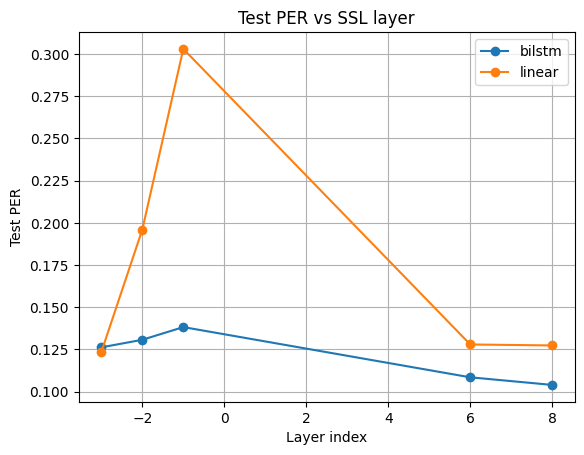

In [153]:
import matplotlib.pyplot as plt

for head_name in results_df["head"].unique():
    subset = results_df[results_df["head"] == head_name].sort_values("layer_index")
    plt.plot(subset["layer_index"], subset["test_per"], marker="o", label=head_name)

plt.xlabel("Layer index")
plt.ylabel("Test PER")
plt.title("Test PER vs SSL layer")
plt.legend()
plt.grid(True)
plt.show()

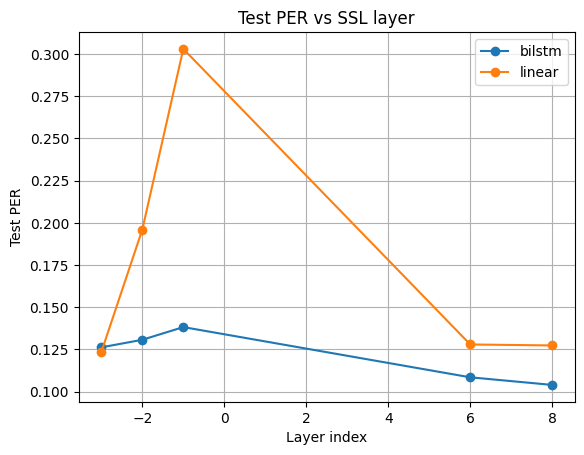

In [154]:
import matplotlib.pyplot as plt

for head_name in results_df["head"].unique():
    subset = results_df[results_df["head"] == head_name].sort_values("layer_index")
    plt.plot(subset["layer_index"], subset["test_per"], marker="o", label=head_name)

plt.xlabel("Layer index")
plt.ylabel("Test PER")
plt.title("Test PER vs SSL layer")
plt.legend()
plt.grid(True)
plt.show()

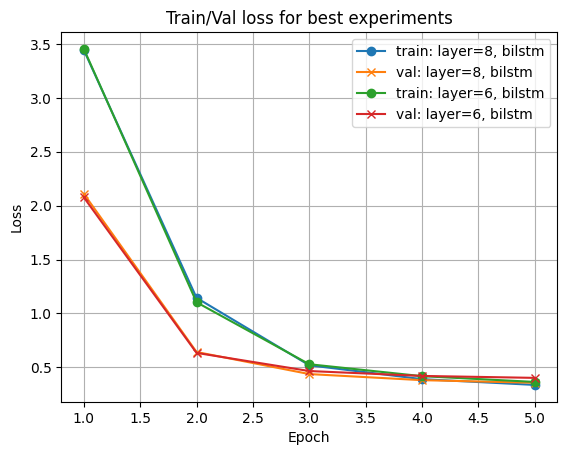

In [155]:
best_rows = results_df.head(2)[["layer_index", "head"]].values.tolist()

for layer_index, head_name in best_rows:
    subset = history_df[
        (history_df["layer_index"] == layer_index) &
        (history_df["head"] == head_name)
    ]

    plt.plot(subset["epoch"], subset["train_loss"], marker="o", label=f"train: layer={layer_index}, {head_name}")
    plt.plot(subset["epoch"], subset["val_loss"], marker="x", label=f"val: layer={layer_index}, {head_name}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Val loss for best experiments")
plt.legend()
plt.grid(True)
plt.show()